## Import libraries


In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

## Clean up data

In [23]:
d = pd.read_csv('/home/suupatruupa/Documents/OLD_code/Machine-Learning/Supervised-Learning/Coursel-L3/Sesh 3/attachment_51358_height_homework.csv(1).csv')
d.head(10)

,Child,Age,Height_cm
0,Alice,5.0,110.0
1,Bob,6.0,115.0
2,Charlie,NaN,120.0
3,David,8.0,125.0
4,Eva,9.0,NaN
5,Frank,10.0,135.0
6,Grace,11.0,140.0
7,Hannah,12.0,145.0
8,Ian,NaN,150.0
9,Jack,14.0,155.0


In [24]:
print(d.isna().sum()) # age 2, height 1
print(d.duplicated().sum()) 

Child        0
Age          2
Height_cm    1
dtype: int64
1


In [25]:
d.fillna(d.mean(numeric_only=True), inplace=True)

,Child,Age,Height_cm
0,Alice,5.000000,110.0
1,Bob,6.000000,115.0
2,Charlie,9.222222,120.0
3,David,8.000000,125.0
4,Eva,9.000000,132.0
5,Frank,10.000000,135.0
6,Grace,11.000000,140.0
7,Hannah,12.000000,145.0
8,Ian,9.222222,150.0
9,Jack,14.000000,155.0


In [26]:
d.drop_duplicates(inplace=True)


In [27]:
d

,Child,Age,Height_cm
0,Alice,5.000000,110.0
1,Bob,6.000000,115.0
2,Charlie,9.222222,120.0
3,David,8.000000,125.0
4,Eva,9.000000,132.0
5,Frank,10.000000,135.0
6,Grace,11.000000,140.0
7,Hannah,12.000000,145.0
8,Ian,9.222222,150.0
9,Jack,14.000000,155.0


## Visualise

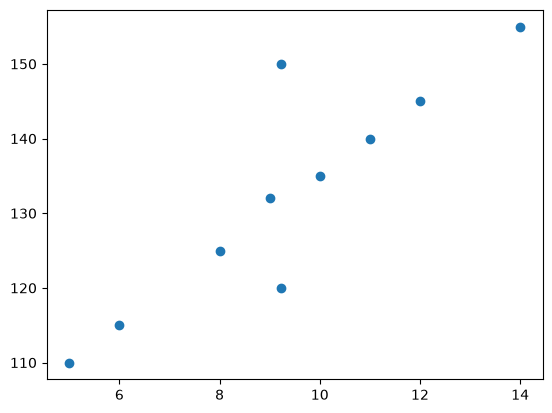

In [28]:
plt.scatter(data=d, x='Age', y='Height_cm')
plt.show()

In [29]:
#x = d[['Age']]
#y = d['Height_cm']
x = d.iloc[:, 1:2]
y = d.iloc[:, 2:3].values

In [30]:
print(x)
print(y)

         Age
0   5.000000
1   6.000000
2   9.222222
3   8.000000
4   9.000000
5  10.000000
6  11.000000
7  12.000000
8   9.222222
9  14.000000
[[110.]
 [115.]
 [120.]
 [125.]
 [132.]
 [135.]
 [140.]
 [145.]
 [150.]
 [155.]]


## Train

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [32]:
print(x_train, x_test, y_train, y_test)

         Age
8   9.222222
0   5.000000
7  12.000000
4   9.000000
6  11.000000
9  14.000000
5  10.000000
3   8.000000         Age
1  6.000000
2  9.222222 [[150.]
 [110.]
 [145.]
 [132.]
 [140.]
 [155.]
 [135.]
 [125.]] [[115.]
 [120.]]


In [33]:
LN= LinearRegression()
LN.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[4.76]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[89.91]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [34]:
pred = LN.predict(x_test)
print(pred)
print(y_test)

[[118.5       ]
 [133.85294118]]
[[115.]
 [120.]]


### Normal scale

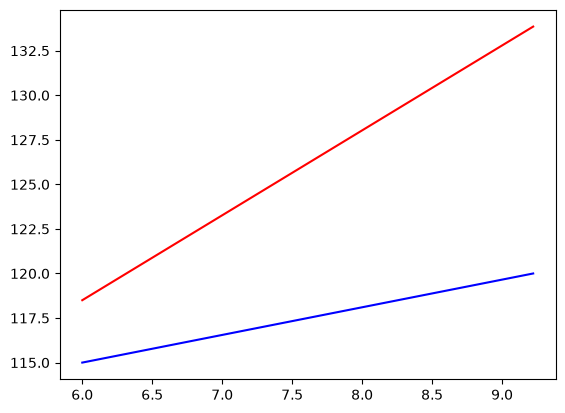

In [35]:
plt.plot(x_test, y_test, color='blue', label='Actual')
plt.plot(x_test, pred, color='red', label='Predicted')
plt.show()

### Standard Scaling

In [36]:
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)
y_train_sc = sc.fit_transform(y_train)
y_test_sc = sc.transform(y_test)

In [37]:
LN.fit(x_train_sc, y_train_sc)
pred_sc = LN.predict(x_test_sc)
print(y_test_sc)
print(pred_sc)

[[-1.58824124]
 [-1.21888281]]
[[-1.32969034]
 [-0.1955427 ]]


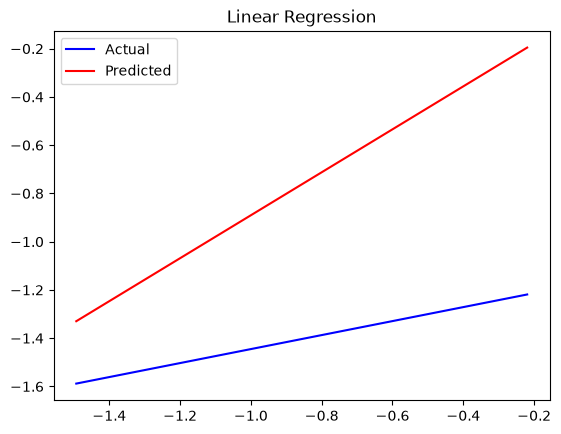

In [38]:
plt.plot(x_test_sc, y_test_sc, color='blue', label='Actual')
plt.plot(x_test_sc, pred_sc, color='red', label='Predicted')
plt.title('Linear Regression')
plt.legend()
plt.show()